In [8]:
!pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/c6/99/ed35197a158f1fdc2fe7c3680e9c70d0128f662e1fee4ed495f4b5e13db0/scikit_learn-1.7.2-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/1e/e8/685f47e0d754320684db4425a0967f7d3fa70126bffd76110b7009a0090f/joblib-1.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
    --------------------------------------- 0.1/8.7 MB 2.4 MB/s eta 0:00:04
   - -------------------------------------- 0.3/8.7 MB 3.3 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.7 MB 3.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/8.7 MB 3.8 MB/s


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install pandas

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/86/41/585a168330ff063014880a80d744219dbf1dd7a1c706e75ab3425a987384/pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for tzdata>=2022.7 from https://files.pythonhosted.org/packages/5c/23/c7abc0ca0a1526a0774eca151daeb8de62ec457e77262b66b359c3c7679e/tzdata-2025.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.0 MB 2.6 MB/s eta 0:00:05
    --------------------------------------- 0.3/11.0 MB 3.2 MB/s eta 0:00:04
   - -------------------------------------- 0.4/11.0 MB 3.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/11.0 MB 3.3 MB/s eta 0:00:04



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tqdm

  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ---------------------------------------- 78.5/78.5 kB 4.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install tensorflow opencv-python mediapipe

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/f9/37/b97abb360b551fbf5870a0ee07e39ff9c655e6e3e2f839bc88be81361842/tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/fa/80/eb88edc2e2b11cd2dd2e56f1c80b5784d11d6e6b7f04a1145df64df40065/opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency information for mediapipe from https://files.pythonhosted.org/packages/b7/79/b77808f8195f229ef0c15875540dfdd36724748a4b3de53d993f23336839/mediapipe-0.10.21-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/8f/aa/ba0014cc4659328dc818a28827be78e6d97312ab0cb98105a770924dc11e/absl_py-2.3.1-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af60


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Verifying of environment

In [1]:
import cv2
import mediapipe as mp

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

# Start video capture
cap = cv2.VideoCapture(0)

print("Environment verified. Press 'q' to exit.")

while cap.isOpened():
    success, image = cap.read()
    if not success:
        print("Ignoring empty camera frame.")
        continue

    # Convert the image to RGB for MediaPipe
    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = hands.process(image)

    # Draw the hand annotations on the image
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Print wrist landmark coordinates (landmark 0)
            print(f'Wrist coordinates: {hand_landmarks.landmark}')
            mp_drawing.draw_landmarks(
                image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS)
    
    cv2.imshow('MediaPipe Verification', image)
    if cv2.waitKey(5) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Environment verified. Press 'q' to exit.
Wrist coordinates: [x: 0.34085077
y: 0.805104136
z: 2.90396542e-007
, x: 0.373848945
y: 0.734235048
z: 0.0333108529
, x: 0.429406226
y: 0.704911113
z: 0.0403557867
, x: 0.475756705
y: 0.698593616
z: 0.0388183631
, x: 0.512137532
y: 0.707998276
z: 0.0355329551
, x: 0.461665273
y: 0.667711377
z: 0.018289268
, x: 0.538021386
y: 0.698789954
z: 0.0184708796
, x: 0.574438751
y: 0.726269305
z: 0.0205001347
, x: 0.598282576
y: 0.752884626
z: 0.0226351488
, x: 0.469703525
y: 0.691841781
z: -0.00381623255
, x: 0.549671948
y: 0.75041151
z: -0.00351479
, x: 0.568900228
y: 0.804437101
z: -0.0019965372
, x: 0.572178066
y: 0.844688
z: 0.000332539057
, x: 0.470980346
y: 0.731816947
z: -0.0227033906
, x: 0.545381188
y: 0.791206896
z: -0.0201618075
, x: 0.563787639
y: 0.841326952
z: -0.0171213746
, x: 0.567893088
y: 0.876596808
z: -0.0148766842
, x: 0.468109936
y: 0.777194381
z: -0.0389868096
, x: 0.528261125
y: 0.815460443
z: -0.0310822856
, x: 0.54910624
y: 0.8

# Processing of data

In [2]:
import os
import cv2
import mediapipe as mp
import pandas as pd
from tqdm import tqdm

# INITIAL CONFIGURATION 
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

DATA_DIR = './datos' 

# PROCESSING AND EXTRACTION
data = []
labels = []

print("Starting image processing ...")

for label in sorted(os.listdir(DATA_DIR)):
    label_path = os.path.join(DATA_DIR, label)
    if not os.path.isdir(label_path):
        continue

    image_files = os.listdir(label_path)
    for img_file in tqdm(image_files, desc=f'Processing letter "{label}"'):
        img_path = os.path.join(label_path, img_file)
        image_landmarks = []
        
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)
        
        if results.multi_hand_landmarks:
            # We iterate over the list of detected hands.
            for single_hand_landmarks in results.multi_hand_landmarks:
                # And now, we iterate over the points of that specific hand.
                for landmark in single_hand_landmarks.landmark:
                    image_landmarks.extend([landmark.x, landmark.y, landmark.z])
            
            data.append(image_landmarks)
            labels.append(label)

print("\nProcessing completed.")
hands.close()

# Saving the data as a DATAFRAME
df = pd.DataFrame(data)
df['label'] = labels

output_path = 'hand_landmarks.csv'
df.to_csv(output_path, index=False)

print(f"\ Success! File'{output_path}' created with {len(df)} samples.")
print(df.head())

<>:56: SyntaxWarning: invalid escape sequence '\ '
<>:56: SyntaxWarning: invalid escape sequence '\ '
C:\Users\sebit\AppData\Local\Temp\ipykernel_22980\2466546782.py:56: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Success! File'{output_path}' created with {len(df)} samples.")


Starting image processing ...


Processing letter "Y": 100%|██████████| 6/6 [00:00<00:00,  9.57it/s]


Processing completed.
\ Success! File'hand_landmarks.csv' created with 134 samples.
          0         1             2         3         4         5         6  \
0  0.442946  0.648411 -5.140160e-07  0.536166  0.638188 -0.041023  0.627152   
1  0.445747  0.680377 -6.031493e-07  0.549496  0.663218 -0.047296  0.643297   
2  0.416655  0.697396 -4.877654e-07  0.487387  0.662521 -0.046355  0.543820   
3  0.452388  0.610972 -1.227231e-07  0.536222  0.597218 -0.126645  0.638510   
4  0.248960  0.645364 -5.097547e-07  0.352673  0.626319 -0.071727  0.451726   

          7         8         9  ...        54        55        56        57  \
0  0.584956 -0.053849  0.702432  ...  0.411305  0.477340 -0.033975  0.417014   
1  0.617286 -0.068379  0.726660  ...  0.417196  0.475429 -0.024500  0.418499   
2  0.603827 -0.061436  0.593352  ...  0.297373  0.509153 -0.014398  0.314182   
3  0.542641 -0.185464  0.737647  ...  0.353265  0.426083 -0.042856  0.369960   
4  0.577151 -0.109207  0.536334  ...  0.

## Training model


Starting the model training (with more eras)...
Training completed.


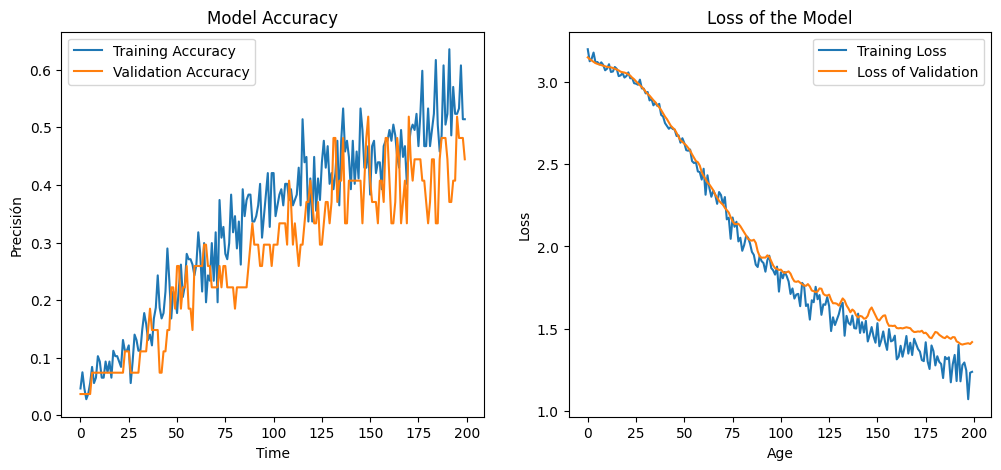

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4444 - loss: 1.4177



Model accuracy in test data: 44.44%

¡Improved model saved as 'lsc_model_A_v2.h5'!


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('hand_landmarks.csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
num_classes = len(np.unique(y_encoded))

# Build the model ---
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN THE MODEL (With more ages to allow time for learning)
print("\nStarting the model training (with more eras)...")
# We increased the ages because the model has more to learn from the augmented data.
history = model.fit(
    X_train, 
    y_train, 
    epochs=200, # we increase upto 200 ages
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=0 
)
print("Training completed.")

#VISUALIZE AND EVALUATE THE MODEL

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Time')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Loss of Validation')
plt.title('Loss of the Model')
plt.xlabel('Age')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Evaluate the final performance of the model using the test data.
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel accuracy in test data: {accuracy * 100:.2f}%")

# Save the trained model
model.save('lsc_model_A_v2.h5')
print("\n¡Improved model saved as 'lsc_model_A_v2.h5'!")

## Validation of the model in real time

In [4]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import string # Para obtener el abecedario fácilmente

# --- 1. CARGAR MODELO Y CONFIGURACIÓN ---

# Carga el modelo de red neuronal que entrenamos lsc_model_A_v2.
model = tf.keras.models.load_model('lsc_model_A_v2.h5')

# Inicializa MediaPipe Hands.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.7)
mp_drawing = mp.solutions.drawing_utils

# --- 2. PREPARAR EL TRADUCTOR DE ETIQUETAS ---
# Es CRUCIAL que las etiquetas aquí estén en el mismo orden que durante el entrenamiento.
# El script de procesamiento las ordenó alfabéticamente, así que hacemos lo mismo aquí.
# NOTA: Asumimos el alfabeto español estándar de 27 letras. Si usaste otras, ajústalo.
labels_list = list(string.ascii_uppercase) + ['Ñ']
labels_list.sort() # Aseguramos el orden alfabético

# Creamos el codificador y lo "entrenamos" con nuestra lista de etiquetas.
# Esto asegura que el número 0 corresponda a 'A', 1 a 'B', etc., igual que en el entrenamiento.
label_encoder = LabelEncoder()
label_encoder.fit(labels_list)


# --- 3. BUCLE PRINCIPAL DE LA APLICACIÓN ---

# Inicia la captura de video desde la cámara web (la cámara 0).
cap = cv2.VideoCapture(0)

print("Iniciando aplicación... Presiona 'q' para salir.")

while cap.isOpened():
    # Lee un fotograma de la cámara.
    success, frame = cap.read()
    if not success:
        print("No se pudo leer el fotograma de la cámara.")
        break

    # Voltea el fotograma horizontalmente para un efecto espejo más intuitivo.
    frame = cv2.flip(frame, 1)
    
    # Guarda las dimensiones del fotograma.
    frame_h, frame_w, _ = frame.shape

    # Convierte la imagen de BGR (OpenCV) a RGB (MediaPipe).
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Procesa la imagen para detectar manos.
    results = hands.process(rgb_frame)

    # Si se detecta una mano...
    if results.multi_hand_landmarks:
        # Dibuja los puntos y las conexiones de la mano en el fotograma.
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # --- PREPARACIÓN DE DATOS PARA EL MODELO ---
            landmarks_data = []
            for landmark in hand_landmarks.landmark:
                landmarks_data.extend([landmark.x, landmark.y, landmark.z])
            
            # Convierte la lista a un array de NumPy y ajústalo a la forma que el modelo espera.
            # El modelo fue entrenado con lotes de datos, así que necesita un array 2D: (1, 63).
            input_data = np.expand_dims(landmarks_data, axis=0)

            # --- PREDICCIÓN DEL MODELO ---
            prediction = model.predict(input_data, verbose=0)
            predicted_index = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # Traduce el índice predicho de nuevo a una letra.
            predicted_letter = label_encoder.inverse_transform([predicted_index])

            # --- VISUALIZACIÓN DEL RESULTADO (SECCIÓN MODIFICADA) ---
            # Dibuja un rectángulo de fondo más pequeño y ajustado.
            cv2.rectangle(frame, (10, 10), (220, 85), (0, 0, 0), -1)
            
            # Muestra la letra predicha con una fuente más pequeña y delgada.
            cv2.putText(frame, f"Letra: {predicted_letter}", (20, 45), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2, cv2.LINE_AA)
            
            # Muestra la confianza con una fuente aún más pequeña para que sea secundaria.
            cv2.putText(frame, f"Confianza: {confidence:.2f}", (20, 70), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

    # Muestra el fotograma final en una ventana.
    cv2.imshow('Reconocimiento LSC en Tiempo Real', frame)

    # Si se presiona la tecla 'q', se rompe el bucle y se cierra la aplicación.
    if cv2.waitKey(5) & 0xFF == ord('q'):
        break

# Libera la cámara y cierra todas las ventanas de OpenCV.
cap.release()
cv2.destroyAllWindows()
print("Aplicación cerrada.")

Iniciando aplicación... Presiona 'q' para salir.
Aplicación cerrada.
